# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [1]:
import pandas as pd
from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data
from scapy.all import *

In [2]:
pcap = PCAP('C:/Users/merin/ml-systems-copy/docs/notebooks/data/netflix.pcap', flow_ptks_thres=5, verbose=10)

In [3]:
pcap.pcap2pandas()
netflix = pcap.df

In [4]:
netflix

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
0,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,55697.0,UDP,1518358200.534682,0.000000
1,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,59884.0,UDP,1518358200.534832,0.000150
2,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,61223.0,UDP,1518358200.539408,0.004726
3,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,58785.0,UDP,1518358200.541204,0.006522
4,2018-02-11 15:10:00,"(ytimg.l.google.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,51938.0,UDP,1518358200.545785,0.011103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141466,2018-02-11 15:18:16,None,None,52.208.128.101,8.860796e+08,192.168.43.72,3.232247e+09,False,54,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58518.0,TCP,1518358696.299107,495.764425
141467,2018-02-11 15:18:16,None,None,52.208.128.101,8.860796e+08,192.168.43.72,3.232247e+09,False,54,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58518.0,TCP,1518358696.299132,495.764450
141468,2018-02-11 15:18:16,None,None,104.31.113.215,1.746891e+09,192.168.43.72,3.232247e+09,False,54,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,80.0,58530.0,TCP,1518358696.299136,495.764454
141469,2018-02-11 15:18:16,None,None,192.168.43.72,3.232247e+09,172.217.18.195,2.899907e+09,False,66,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,58514.0,443.0,TCP,1518358696.313540,495.778858


### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [5]:
dns_netflix = netflix.loc[netflix["is_dns"] == True]
dns_netflix #get this back to pcap or filter pcap

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
0,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,55697.0,UDP,1518358200.534682,0.000000
1,2018-02-11 15:10:00,"(fonts.gstatic.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,77,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,59884.0,UDP,1518358200.534832,0.000150
2,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,61223.0,UDP,1518358200.539408,0.004726
3,2018-02-11 15:10:00,"(googleads.g.doubleclick.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,87,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,58785.0,UDP,1518358200.541204,0.006522
4,2018-02-11 15:10:00,"(ytimg.l.google.com.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,51938.0,UDP,1518358200.545785,0.011103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141239,2018-02-11 15:18:12,"(plus.l.google.com.,)","(172.217.18.206,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,87,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,33916.0,53.0,UDP,1518358692.204593,491.669911
141245,2018-02-11 15:18:12,"(www.google.com.,)","(172.217.18.196,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,84,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,56870.0,53.0,UDP,1518358692.217483,491.682801
141246,2018-02-11 15:18:12,"(www.gstatic.com.,)","(216.58.209.227,)",192.168.43.72,3.232247e+09,128.93.77.234,2.153598e+09,True,85,e4:ce:8f:01:4c:54,251575813622868,a0:ce:c8:0d:2b:a7,176809980013479,34182.0,53.0,UDP,1518358692.218175,491.683493
141371,2018-02-11 15:18:13,"(freegeoip.net.,)",None,128.93.77.234,2.153598e+09,192.168.43.72,3.232247e+09,True,73,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,53.0,11404.0,UDP,1518358693.222075,492.687393


In [6]:
from scapy.all import rdpcap, DNS

pcap_to_filter = rdpcap('C:/Users/merin/ml-systems-copy/docs/notebooks/data/netflix.pcap')
pcap_list = list(pcap_to_filter)

filter_pcap = [pkt for pkt in pcap_list if DNS in pkt]

In [7]:
wrpcap('netflix_dns_only.pcap', filter_pcap)

In [8]:
dns_pcap = PCAP('C:/Users/merin/ml-systems-copy/docs/assignments/netflix_dns_only.pcap', flow_ptks_thres=4, verbose=10)

### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [9]:
dns_pcap.pcap2flows(q_interval=0.69)

pcap_file: C:/Users/merin/ml-systems-copy/docs/assignments/netflix_dns_only.pcap
ith_packets: 0
len(flows): 99
total number of flows: 99. Num of flows < 4 pkts: 94, and >=4 pkts: 5 without timeout splitting.
kept flows: 5. Each of them has at least 4 pkts after timeout splitting.
flow_durations.shape: (5, 1)
        col_0
count   5.000
mean  285.120
std   235.121
min    13.439
25%    49.799
50%   389.532
75%   486.124
max   486.705
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   5 non-null      float64
dtypes: float64(1)
memory usage: 172.0 bytes
None
0th_flow: len(pkts): 9
After splitting flows, the number of subflows: 5 and each of them has at least 4 packets.


In [10]:
#Feature generation (IAT)
dns_pcap.flow2features('IAT', fft=False, header=False)
iat_features = dns_pcap.features

True


In [11]:
#Feature generation (STATS)
dns_pcap.flow2features('STATS', fft=False, header=False)
stat_features = dns_pcap.features

True


In [12]:
#Feature generation (SIZE)
dns_pcap.flow2features('SIZE', fft=False, header=False)
size_features = dns_pcap.features

True


In [13]:
import numpy as np

print(np.shape(iat_features))
print(np.shape(stat_features))
print(np.shape(size_features))

(5, 10)
(5, 12)
(5, 11)


In [14]:
all_features = np.concatenate((iat_features,stat_features,size_features), axis=1)

**Write a brief justification for the features that you have chosen.**

I think that the IAT features, all the standard measurements and statistics included in STATS, and the time series size information are minimum information needed for this model. IAT and SIZE can help with measure ABR for this video application.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [15]:
dns_pcap.flow2features('SAMP_NUM', fft=False, header=False)
seg_down_features = dns_pcap.features

True


In [16]:
seg_down_features

array([[ 2.,  3.,  1.,  1.,  2.,  0.,  0.,  0.,  0.,  0.],
       [10., 14.,  6.,  2.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 3.,  2.,  4.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [12.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [17]:
video_dataset = pd.read_pickle("C:/Users/merin/Downloads/Data/video_dataset.pkl")
netflix_dataset = pd.read_pickle("C:/Users/merin/Downloads/Data/netflix_dataset.pkl")

In [18]:
video_dataset

,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,L7_all_prev_down_chunk_iat_75,L7_all_prev_down_chunk_iat_85,L7_all_prev_down_chunk_iat_90,L7_all_prev_down_chunk_iat_avg,L7_all_prev_down_chunk_iat_max,L7_all_prev_down_chunk_iat_min,L7_all_prev_down_chunk_iat_std,L7_all_prev_up_chunk_iat_50,L7_all_prev_up_chunk_iat_75,L7_all_prev_up_chunk_iat_85,L7_all_prev_up_chunk_iat_90,L7_all_prev_up_chunk_iat_avg,L7_all_prev_up_chunk_iat_max,L7_all_prev_up_chunk_iat_min,L7_all_prev_up_chunk_iat_std,L7_allprev_avg_chunksize,L7_allprev_chunksizes_50,L7_allprev_chunksizes_75,L7_allprev_chunksizes_85,L7_allprev_chunksizes_90,L7_allprev_max_chunksize,L7_allprev_min_chunksize,L7_allprev_std_chunksize,L7_cumsum_chunksizes,L7_cumsum_diff,L7_down_chunk_iat_50,L7_down_chunk_iat_75,L7_down_chunk_iat_85,L7_down_chunk_iat_90,L7_down_chunk_iat_avg,L7_down_chunk_iat_max,L7_down_chunk_iat_min,L7_down_chunk_iat_std,home_id,index,L7_n_chunks_down,L7_n_chunks_up,L7_n_prev_down_chunk,L7_n_prev_up_chunk,L3_parallel_flows,relative_timestamp,resolution,L3_service_Video_throughput_down,L3_service_Video_throughput_up,L3_service_non_video_throughput_down,L3_service_non_video_throughput_up,session_id,L3_total_throughput_down,L3_total_throughput_up,L7_up_chunk_iat_50,L7_up_chunk_iat_75,L7_up_chunk_iat_85,L7_up_chunk_iat_90,L7_up_chunk_iat_avg,L7_up_chunk_iat_max,L7_up_chunk_iat_min,L7_up_chunk_iat_std,L7_up_down_ratio,video_id,video_position,L4_serverAckFlags,L4_serverAvgBytesInFlight,L4_serverAvgBytesPerPacket,L4_serverAvgRetransmit,L4_serverAvgRwnd,L3_serverByteCount,L4_serverEndBytesPerPacket,L4_serverFinFlags,L4_serverGoodput,L4_serverIdleTime,L4_serverKurBytesInFlight,L4_serverKurBytesPerPacket,L4_serverKurRetransmit,L4_serverKurRwnd,L4_serverMaxBytesInFlight,L4_serverMaxBytesPerPacket,L4_serverMaxRetransmit,L4_serverMaxRwnd,L4_serverMedBytesInFlight,L4_serverMedBytesPerPacket,L4_serverMedRetransmit,L4_serverMedRwnd,L4_serverMinBytesInFlight,L4_serverMinBytesPerPacket,L4_serverMinRetransmit,L4_serverMinRwnd,L4_serverOneRetransmit,L4_serverOutOfOrderBytes,L4_serverOutOfOrderPackets,L3_serverPacketCount,L4_serverPshFlags,L4_serverRstFlags,L4_serverSkeBytesInFlight,L4_serverSkeBytesPerPacket,L4_serverSkeRetransmit,L4_serverSkeRwnd,L4_serverStdBytesInFlight,L4_serverStdBytesPerPacket,L4_serverStdRetransmit,L4_serverStdRwnd,L4_serverStrBytesPerPacket,L4_serverSynFlags,L4_serverTwoRetransmit,L4_serverUrgFlags,L4_serverXRetransmit,L4_serverZeroRetransmit,L4_userAckFlags,L4_userAvgBytesInFlight,L4_userAvgBytesPerPacket,L4_userAvgRTT,L4_userAvgRetransmit,L4_userAvgRwnd,L3_userByteCount,L4_userEndBytesInFlight,L4_userFinFlags,L4_userGoodput,L4_userIdleTime,L4_userKurBytesInFlight,L4_userKurBytesPerPacket,L4_userKurRTT,L4_userKurRetransmit,L4_userKurRwnd,L4_userMaxBytesInFlight,L4_userMaxBytesPerPacket,L4_userMaxRTT,L4_userMaxRetransmit,L4_userMaxRwnd,L4_userMedBytesInFlight,L4_userMedBytesPerPacket,L4_userMedRTT,L4_userMedRetransmit,L4_userMedRwnd,L4_userMinBytesInFlight,L4_userMinBytesPerPacket,L4_userMinRTT,L4_userMinRetransmit,L4_userMinRwnd,L4_userOneRetransmit,L4_userOutOfOrderBytes,L4_userOutOfOrderPackets,L3_userPacketCount,L4_userPshFlags,L4_userRstFlags,L4_userSkeBytesInFlight,L4_userSkeBytesPerPacket,L4_userSkeRTT,L4_userSkeRetransmit,L4_userSkeRwnd,L4_userStdBytesInFlight,L4_userStdBytesPerPacket,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.100,43473.000,185098.000,361832.300,461040.200,539882,4380,185126.042,1548881398.366,161.500,602.500,2256.650,3144.300,808.400,3318,34,1223.071,38.000,216.500,860.000,1481.000,682.727,5450,0,1562.875,135804.636,24500.000,176338.000,323069.000,452280.000,539882,4380,181337.504,1493851,0,161.500,602.500,2256.650,3144.300,808.400,33

### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [19]:
valid_res = [240, 360, 480, 720, 1080]
valid_res_vids = video_dataset.loc[video_dataset["resolution"].isin(valid_res)]

2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [20]:
column_to_remove = ["home_id", "index", "RTT", "serverSynFlags", "serverTwoRetransmit", "serverUrgFlags", "serverXRetransmit", 
                    "serverZeroRetransmit", "userAckFlags", "chunksizes_", "all_prev_down_chunk_iat",
                    "all_prev_up_chunk_iat", "allprev_chunksizes_", "down_chunk_iat_", "n_chunks_down", "n_chunks_up",
                    "n_prev_down_chunk", "n_prev_up_chunk"]

In [21]:
cols_to_drop = [
    col for col in valid_res_vids.columns
    if any(pat.lower() in col.lower() for pat in column_to_remove)
]
valid_res_vids_reduced = valid_res_vids.drop(columns=cols_to_drop)

In [22]:
valid_res_vids_reduced

,L7_10_avg_chunksize,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_allprev_avg_chunksize,L7_allprev_max_chunksize,L7_allprev_min_chunksize,L7_allprev_std_chunksize,L7_cumsum_chunksizes,L7_cumsum_diff,L3_parallel_flows,relative_timestamp,resolution,L3_service_Video_throughput_down,L3_service_Video_throughput_up,L3_service_non_video_throughput_down,L3_service_non_video_throughput_up,session_id,L3_total_throughput_down,L3_total_throughput_up,L7_up_chunk_iat_50,L7_up_chunk_iat_75,L7_up_chunk_iat_85,L7_up_chunk_iat_90,L7_up_chunk_iat_avg,L7_up_chunk_iat_max,L7_up_chunk_iat_min,L7_up_chunk_iat_std,L7_up_down_ratio,video_id,video_position,L4_serverAckFlags,L4_serverAvgBytesInFlight,L4_serverAvgBytesPerPacket,L4_serverAvgRetransmit,L4_serverAvgRwnd,L3_serverByteCount,L4_serverEndBytesPerPacket,L4_serverFinFlags,L4_serverGoodput,L4_serverIdleTime,L4_serverKurBytesInFlight,L4_serverKurBytesPerPacket,L4_serverKurRetransmit,L4_serverKurRwnd,L4_serverMaxBytesInFlight,L4_serverMaxBytesPerPacket,L4_serverMaxRetransmit,L4_serverMaxRwnd,L4_serverMedBytesInFlight,L4_serverMedBytesPerPacket,L4_serverMedRetransmit,L4_serverMedRwnd,L4_serverMinBytesInFlight,L4_serverMinBytesPerPacket,L4_serverMinRetransmit,L4_serverMinRwnd,L4_serverOneRetransmit,L4_serverOutOfOrderBytes,L4_serverOutOfOrderPackets,L3_serverPacketCount,L4_serverPshFlags,L4_serverRstFlags,L4_serverSkeBytesInFlight,L4_serverSkeBytesPerPacket,L4_serverSkeRetransmit,L4_serverSkeRwnd,L4_serverStdBytesInFlight,L4_serverStdBytesPerPacket,L4_serverStdRetransmit,L4_serverStdRwnd,L4_serverStrBytesPerPacket,L4_userAvgBytesInFlight,L4_userAvgBytesPerPacket,L4_userAvgRetransmit,L4_userAvgRwnd,L3_userByteCount,L4_userEndBytesInFlight,L4_userFinFlags,L4_userGoodput,L4_userIdleTime,L4_userKurBytesInFlight,L4_userKurBytesPerPacket,L4_userKurRetransmit,L4_userKurRwnd,L4_userMaxBytesInFlight,L4_userMaxBytesPerPacket,L4_userMaxRetransmit,L4_userMaxRwnd,L4_userMedBytesInFlight,L4_userMedBytesPerPacket,L4_userMedRetransmit,L4_userMedRwnd,L4_userMinBytesInFlight,L4_userMinBytesPerPacket,L4_userMinRetransmit,L4_userMinRwnd,L4_userOneRetransmit,L4_userOutOfOrderBytes,L4_userOutOfOrderPackets,L3_userPacketCount,L4_userPshFlags,L4_userRstFlags,L4_userSkeBytesInFlight,L4_userSkeBytesPerPacket,L4_userSkeRetransmit,L4_userSkeRwnd,L4_userStdBytesInFlight,L4_userStdBytesPerPacket,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.100,539882,4380,185126.042,1548881398.366,135804.636,539882,4380,181337.504,1493851,0,4,10.000,360.000,1486.592,56.521,0.016,0.000,7ff91b2519956acd8d59932235005743,1612.879,57.181,38.000,38.000,38.000,38.000,682.727,5450,0,1562.875,1,70196252,10.000,810,10783.617,1408.790,0.000,2363.505,1141120,39583,0,0.000,0.000,3.746,23.157,-3.000,197.505,56940,1460,0,65535,5840.000,1460.000,0.000,2050.000,1,0,0,2049,0.000,1141120,806,810,25,0,2.116,-4.871,0.000,14.125,13380.852,239.754,0.000,4450.242,0,294.812,14.287,21.680,16250.672,8101,0,0,0.000,0.000,-1.459,49.170,3.894,55.888,809,755,202,16425,126.000,0.000,0.000,16425.000,0,0,0,6570,0.000,0,0,567,17,0,0.573,7.046,2.395,-7.238,330.414,94.051,57.463,985.136,0,4,0.000,0,0.109,0.558,netflix
1,91984.200,196778,24498,62449.107,1548881408.366,116377.194,539882,4380,123554.059,3607693,2113842,5,20.000,360.000,1808.675,35.790,0.008,0.000,7ff91b2519956acd8d59932235005743,3314.766,36.385,322.000,322.000,322.000,322.000,461.619,1824,0,542.721,2,70196252,20.000,1164,6510.163,1394.361,0.000,2104.540,1623036,20109,0,0.000,0.000,0.757,15.998,-3.000,1159.001,21900,1460,0,65535,5840.000,1460.000,0.000,2050.000,1,0,0,2049,0.000,247560,187,1164,37,0,1.135,-4.088,0.000,34.073,4920.970,261.481,0.000,1859.979,34227,353.333,20.528,26.571,16396.571,15848,0,0,0.000,0.000,-1.962,30.823,6.010,631.922,757,757,287,16425,51.000,0.000,0.000,16425.000,0,0,0,8192,0.000,0,0,772,23,0,0.073,5.715,2.682,-24.153,361.140,119.847,71

In [23]:
test_cols_to_remove = []

for feat in valid_res_vids.columns:
    if feat in column_to_remove:
        test_cols_to_remove.append(feat)

test_cols_to_remove

['home_id', 'index']

In [24]:
test_dfs = []
cols_to_loc = []

for i in range(len(column_to_remove)):
    trial = valid_res_vids.filter(like=column_to_remove[i])
    test_dfs.append(trial)
    i += 1

for i in range(len(test_dfs)):
    trial_to_loc = test_dfs[i].columns[0]

    cols_to_loc.append(trial_to_loc)
    i += 1

cols_to_loc

['home_id',
 'index',
 'L4_userAvgRTT',
 'L4_serverSynFlags',
 'L4_serverTwoRetransmit',
 'L4_serverUrgFlags',
 'L4_serverXRetransmit',
 'L4_serverZeroRetransmit',
 'L4_userAckFlags',
 'L7_10_chunksizes_50',
 'L7_all_prev_down_chunk_iat_50',
 'L7_all_prev_up_chunk_iat_50',
 'L7_allprev_chunksizes_50',
 'L7_all_prev_down_chunk_iat_50',
 'L7_n_chunks_down',
 'L7_n_chunks_up',
 'L7_n_prev_down_chunk',
 'L7_n_prev_up_chunk']

In [25]:
valid_res_vids.drop(columns=cols_to_loc)

,L7_10_avg_chunksize,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_75,L7_all_prev_down_chunk_iat_85,L7_all_prev_down_chunk_iat_90,L7_all_prev_down_chunk_iat_avg,L7_all_prev_down_chunk_iat_max,L7_all_prev_down_chunk_iat_min,L7_all_prev_down_chunk_iat_std,L7_all_prev_up_chunk_iat_75,L7_all_prev_up_chunk_iat_85,L7_all_prev_up_chunk_iat_90,L7_all_prev_up_chunk_iat_avg,L7_all_prev_up_chunk_iat_max,L7_all_prev_up_chunk_iat_min,L7_all_prev_up_chunk_iat_std,L7_allprev_avg_chunksize,L7_allprev_chunksizes_75,L7_allprev_chunksizes_85,L7_allprev_chunksizes_90,L7_allprev_max_chunksize,L7_allprev_min_chunksize,L7_allprev_std_chunksize,L7_cumsum_chunksizes,L7_cumsum_diff,L7_down_chunk_iat_50,L7_down_chunk_iat_75,L7_down_chunk_iat_85,L7_down_chunk_iat_90,L7_down_chunk_iat_avg,L7_down_chunk_iat_max,L7_down_chunk_iat_min,L7_down_chunk_iat_std,L3_parallel_flows,relative_timestamp,resolution,L3_service_Video_throughput_down,L3_service_Video_throughput_up,L3_service_non_video_throughput_down,L3_service_non_video_throughput_up,session_id,L3_total_throughput_down,L3_total_throughput_up,L7_up_chunk_iat_50,L7_up_chunk_iat_75,L7_up_chunk_iat_85,L7_up_chunk_iat_90,L7_up_chunk_iat_avg,L7_up_chunk_iat_max,L7_up_chunk_iat_min,L7_up_chunk_iat_std,L7_up_down_ratio,video_id,video_position,L4_serverAckFlags,L4_serverAvgBytesInFlight,L4_serverAvgBytesPerPacket,L4_serverAvgRetransmit,L4_serverAvgRwnd,L3_serverByteCount,L4_serverEndBytesPerPacket,L4_serverFinFlags,L4_serverGoodput,L4_serverIdleTime,L4_serverKurBytesInFlight,L4_serverKurBytesPerPacket,L4_serverKurRetransmit,L4_serverKurRwnd,L4_serverMaxBytesInFlight,L4_serverMaxBytesPerPacket,L4_serverMaxRetransmit,L4_serverMaxRwnd,L4_serverMedBytesInFlight,L4_serverMedBytesPerPacket,L4_serverMedRetransmit,L4_serverMedRwnd,L4_serverMinBytesInFlight,L4_serverMinBytesPerPacket,L4_serverMinRetransmit,L4_serverMinRwnd,L4_serverOneRetransmit,L4_serverOutOfOrderBytes,L4_serverOutOfOrderPackets,L3_serverPacketCount,L4_serverPshFlags,L4_serverRstFlags,L4_serverSkeBytesInFlight,L4_serverSkeBytesPerPacket,L4_serverSkeRetransmit,L4_serverSkeRwnd,L4_serverStdBytesInFlight,L4_serverStdBytesPerPacket,L4_serverStdRetransmit,L4_serverStdRwnd,L4_serverStrBytesPerPacket,L4_userAvgBytesInFlight,L4_userAvgBytesPerPacket,L4_userAvgRetransmit,L4_userAvgRwnd,L3_userByteCount,L4_userEndBytesInFlight,L4_userFinFlags,L4_userGoodput,L4_userIdleTime,L4_userKurBytesInFlight,L4_userKurBytesPerPacket,L4_userKurRTT,L4_userKurRetransmit,L4_userKurRwnd,L4_userMaxBytesInFlight,L4_userMaxBytesPerPacket,L4_userMaxRTT,L4_userMaxRetransmit,L4_userMaxRwnd,L4_userMedBytesInFlight,L4_userMedBytesPerPacket,L4_userMedRTT,L4_userMedRetransmit,L4_userMedRwnd,L4_userMinBytesInFlight,L4_userMinBytesPerPacket,L4_userMinRTT,L4_userMinRetransmit,L4_userMinRwnd,L4_userOneRetransmit,L4_userOutOfOrderBytes,L4_userOutOfOrderPackets,L3_userPacketCount,L4_userPshFlags,L4_userRstFlags,L4_userSkeBytesInFlight,L4_userSkeBytesPerPacket,L4_userSkeRTT,L4_userSkeRetransmit,L4_userSkeRwnd,L4_userStdBytesInFlight,L4_userStdBytesPerPacket,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.100,185098.000,361832.300,461040.200,539882,4380,185126.042,1548881398.366,602.500,2256.650,3144.300,808.400,3318,34,1223.071,216.500,860.000,1481.000,682.727,5450,0,1562.875,135804.636,176338.000,323069.000,452280.000,539882,4380,181337.504,1493851,0,161.500,602.500,2256.650,3144.300,808.400,3318,34,1223.071,4,10.000,360.000,1486.592,56.521,0.016,0.000,7ff91b2519956acd8d59932235005743,1612.879,57.181,38.000,38.000,38.000,38.000,682.727,5450,0,1562.875,1,70196252,10.000,810,10783.617,1408.790,0.000,2363.505,1141120,39583,0,0.000,0.000,3.746,23.157,-3.000,197.505,56940,1460,0,65535,5840.000,1460.000,0.000,2050.000,1,0,0,2049,0.000,1141120,806,810,

In [26]:
valid_res_vids.columns.values

array(['L7_10_avg_chunksize', 'L7_10_chunksizes_50',
       'L7_10_chunksizes_75', 'L7_10_chunksizes_85',
       'L7_10_chunksizes_90', 'L7_10_max_chunksize',
       'L7_10_min_chunksize', 'L7_10_std_chunksize', 'absolute_timestamp',
       'L7_all_prev_down_chunk_iat_50', 'L7_all_prev_down_chunk_iat_75',
       'L7_all_prev_down_chunk_iat_85', 'L7_all_prev_down_chunk_iat_90',
       'L7_all_prev_down_chunk_iat_avg', 'L7_all_prev_down_chunk_iat_max',
       'L7_all_prev_down_chunk_iat_min', 'L7_all_prev_down_chunk_iat_std',
       'L7_all_prev_up_chunk_iat_50', 'L7_all_prev_up_chunk_iat_75',
       'L7_all_prev_up_chunk_iat_85', 'L7_all_prev_up_chunk_iat_90',
       'L7_all_prev_up_chunk_iat_avg', 'L7_all_prev_up_chunk_iat_max',
       'L7_all_prev_up_chunk_iat_min', 'L7_all_prev_up_chunk_iat_std',
       'L7_allprev_avg_chunksize', 'L7_allprev_chunksizes_50',
       'L7_allprev_chunksizes_75', 'L7_allprev_chunksizes_85',
       'L7_allprev_chunksizes_90', 'L7_allprev_max_chunksize',
 

In [78]:
#Next iteration, Claude Sonnet 5 used to refine down more

column_to_remove = [
    "home_id", "index",
    "RTT",
    "SynFlags", "AckFlags", "FinFlags", "RstFlags", "PshFlags", "UrgFlags",
    "OneRetransmit", "TwoRetransmit", "XRetransmit", "ZeroRetransmit",
    "chunksizes_",
    "L7_all_prev_down_chunk_iat", "L7_all_prev_up_chunk_iat",
    "n_prev_down_chunk", "n_prev_up_chunk", "session_id", "video_id"
]

test_dfs = []
cols_to_loc = []

for i in range(len(column_to_remove)):
    trial = valid_res_vids.filter(like=column_to_remove[i])
    test_dfs.append(trial)
    i += 1

for i in range(len(test_dfs)):
    trial_to_loc = list(test_dfs[i].columns)  # all matches, not just the first

    cols_to_loc.extend(trial_to_loc)
    i += 1

cols_to_loc = list(dict.fromkeys(cols_to_loc))  # dedupe, keep order
cols_to_loc

['home_id',
 'index',
 'L4_userAvgRTT',
 'L4_userKurRTT',
 'L4_userMaxRTT',
 'L4_userMedRTT',
 'L4_userMinRTT',
 'L4_userSkeRTT',
 'L4_userStdRTT',
 'L4_serverSynFlags',
 'L4_userSynFlags',
 'L4_serverAckFlags',
 'L4_userAckFlags',
 'L4_serverFinFlags',
 'L4_userFinFlags',
 'L4_serverRstFlags',
 'L4_userRstFlags',
 'L4_serverPshFlags',
 'L4_userPshFlags',
 'L4_serverUrgFlags',
 'L4_userUrgFlags',
 'L4_serverOneRetransmit',
 'L4_userOneRetransmit',
 'L4_serverTwoRetransmit',
 'L4_userTwoRetransmit',
 'L4_serverXRetransmit',
 'L4_userXRetransmit',
 'L4_serverZeroRetransmit',
 'L4_userZeroRetransmit',
 'L7_10_chunksizes_50',
 'L7_10_chunksizes_75',
 'L7_10_chunksizes_85',
 'L7_10_chunksizes_90',
 'L7_allprev_chunksizes_50',
 'L7_allprev_chunksizes_75',
 'L7_allprev_chunksizes_85',
 'L7_allprev_chunksizes_90',
 'L7_all_prev_down_chunk_iat_50',
 'L7_all_prev_down_chunk_iat_75',
 'L7_all_prev_down_chunk_iat_85',
 'L7_all_prev_down_chunk_iat_90',
 'L7_all_prev_down_chunk_iat_avg',
 'L7_all_pr

In [79]:
ready_vid_set = valid_res_vids.drop(columns=cols_to_loc)

**Briefly explain why you removed those columns.**

I decided to remove some of the chunk size information besides the ones that were summry stats and the flag information because it was irrelevant.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [112]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#Everything else besides resolution (label)

features = ready_vid_set.loc[:, ready_vid_set.columns != "resolution"]
labels = ready_vid_set["resolution"]

le = LabelEncoder()
y_encoded = le.fit_transform(labels)

# LightGBM wants categorical columns as pandas 'category' dtype
features = features.copy()
features["service"] = features["service"].astype("category")

X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    features, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [115]:
from lightgbm import LGBMClassifier

In [116]:
#Used Claude Sonnet 5
lgbm = LGBMClassifier(random_state=42, n_jobs=-1)

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [90]:
from sklearn.model_selection import RandomizedSearchCV

In [117]:
#Used Claude Sonnet 5
param_dist = {
    'n_estimators': [100, 300, 500],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': np.logspace(-3, -1, 5),
    'min_child_samples': [5, 10, 20, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

search = RandomizedSearchCV(
    lgbm, param_distributions=param_dist, 
    n_iter=20, 
    cv=3,
    scoring='f1_macro', 
    n_jobs=-1, 
    random_state=42, 
    verbose=1
)

search.fit(X_train, y_train, categorical_feature=['service'])

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)
best_model = search.best_estimator_
print("Test score:", best_model.score(X_test, y_test))
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24360
[LightGBM] [Info] Number of data points in the train set: 160050, number of used features: 110
[LightGBM] [Info] Start training from score -1.480094
[LightGBM] [Info] Start training from score -1.841919
[LightGBM] [Info] Start training from score -1.007400
[LightGBM] [Info] Start training from score -1.661406
[LightGBM] [Info] Start training from score -2.833076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

In [119]:
cv_model = LGBMClassifier(subsample= 0.8, num_leaves= 127, n_estimators= 500, min_child_samples= 20, max_depth= 10, learning_rate= np.float64(0.1), colsample_bytree= 0.8)
cv_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24360
[LightGBM] [Info] Number of data points in the train set: 160050, number of used features: 110
[LightGBM] [Info] Start training from score -1.480094
[LightGBM] [Info] Start training from score -1.841919
[LightGBM] [Info] Start training from score -1.007400
[LightGBM] [Info] Start training from score -1.661406
[LightGBM] [Info] Start training from score -2.833076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

LGBMClassifier(colsample_bytree=0.8, learning_rate=np.float64(0.1),
               max_depth=10, n_estimators=500, num_leaves=127, subsample=0.8)

In [120]:
#Accuracy
cv_model.score(X_test, y_test)

0.9689600879714093

In [121]:
#F1 score
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='macro')

np.float64(0.9673359840128469)

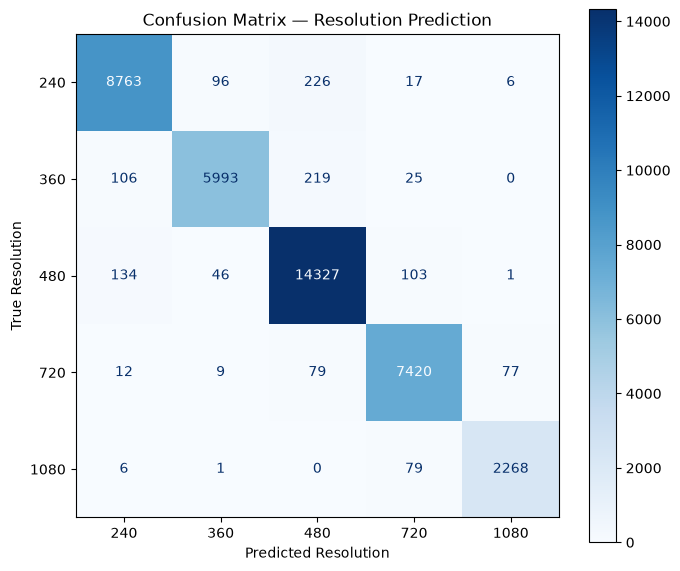

In [ ]:
#Confusion matrix

#Used Claude Sonnet 5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
labels_display = [str(int(c)) for c in le.classes_]

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix — Resolution Prediction")
plt.xlabel("Predicted Resolution")
plt.ylabel("True Resolution")
plt.tight_layout()
plt.show()

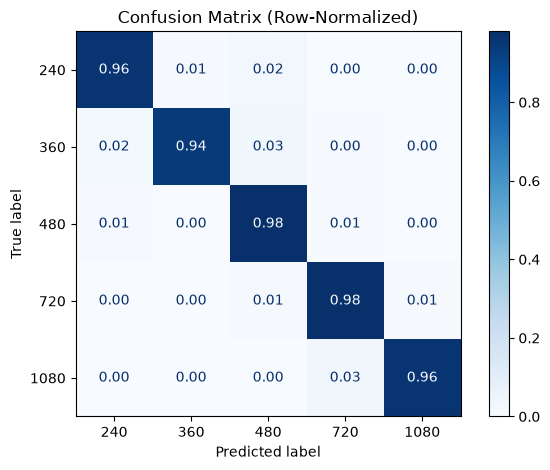

In [ ]:
#Used Claude Sonnet 5
disp_norm = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=labels_display,
    cmap='Blues', normalize='true', values_format='.2f'
)
plt.title("Confusion Matrix (Row-Normalized)")
plt.tight_layout()
plt.show()

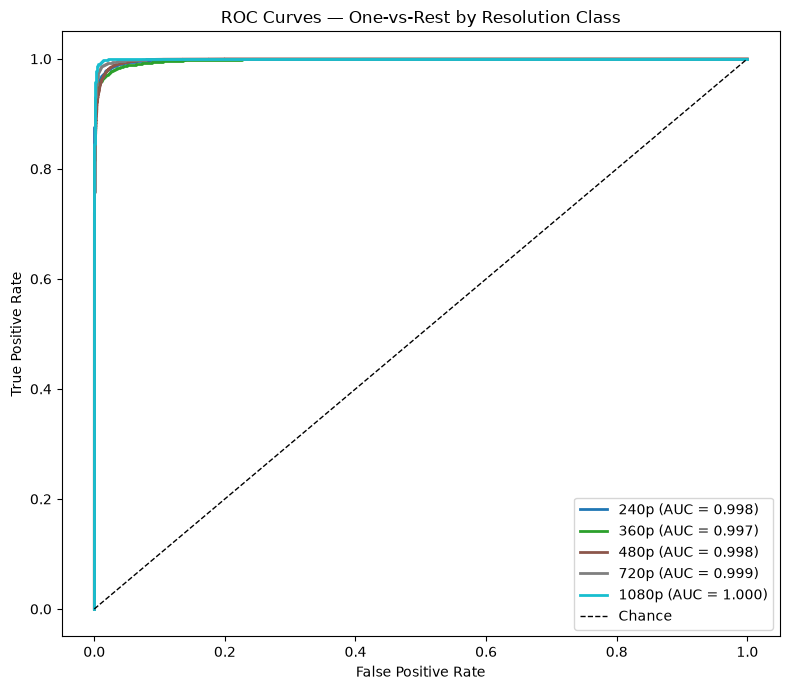

Macro-average AUC: 0.9985
Weighted-average AUC: 0.9983


In [ ]:
#ROC/AUC

#Used Claude Sonnet 5
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Get predicted probabilities
y_proba = best_model.predict_proba(X_test)

# Binarize y_test for OvR ROC (shape: n_samples x n_classes)
classes = best_model.classes_  # encoded labels, e.g. [0,1,2,3,4]
y_test_bin = label_binarize(y_test, classes=classes)

n_classes = len(classes)
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'{int(le.classes_[i])}p (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — One-vs-Rest by Resolution Class')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Summary AUC scores
macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
weighted_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f"Macro-average AUC: {macro_auc:.4f}")
print(f"Weighted-average AUC: {weighted_auc:.4f}")

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

In [127]:
features = ready_vid_set.loc[:, ready_vid_set.columns != "resolution"]
labels = ready_vid_set["resolution"]

le = LabelEncoder()
y_encoded = le.fit_transform(labels)

# LightGBM wants categorical columns as pandas 'category' dtype
features = features.copy()
features["service"] = features["service"].astype("category")

X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    features, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)